### Visualization tools

In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# Reward over time plot

obs = np.load('./observations.npy')
T, n = obs.shape

strategy_string = "Tsallis-INF"

max_reward = np.zeros(T-1)
for t in range(1,T):
    max_reward[t-1] =np.sum(np.max(obs[:t,:], axis = 0)) 

plt.plot(range(1, T), max_reward/n, label = "Reward")
plt.grid()
plt.legend()
plt.ylim([0.7, 1])
plt.xlabel('t')
plt.ylabel("Reward")
plt.title(f'Maximum average reward, using the {strategy_string} strategy')
plt.show()
#plt.savefig('./tsallis_inf_reward_rf1.svg', format ="svg" )

CODE


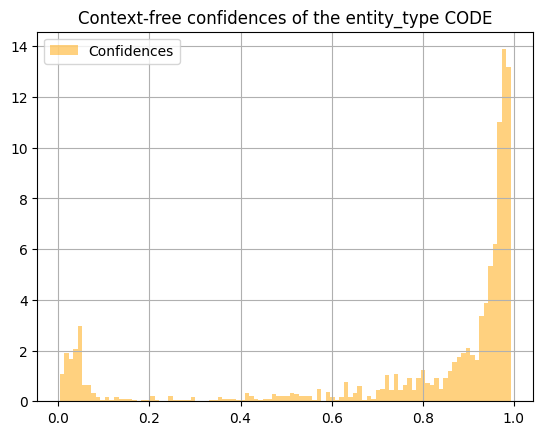

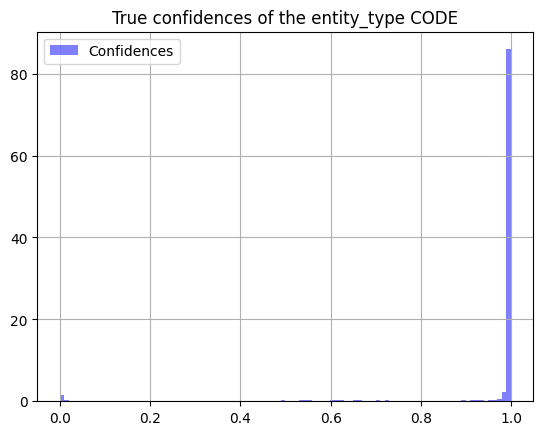

PERSON


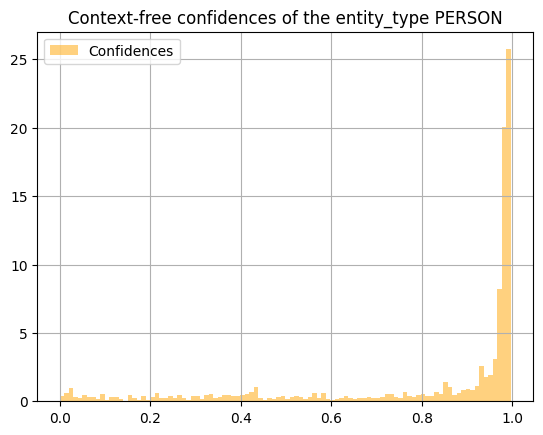

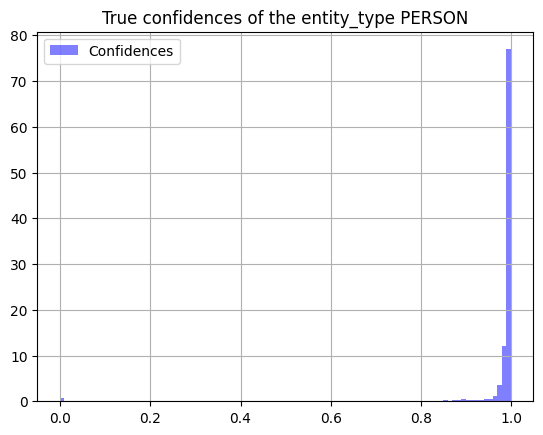

DATETIME


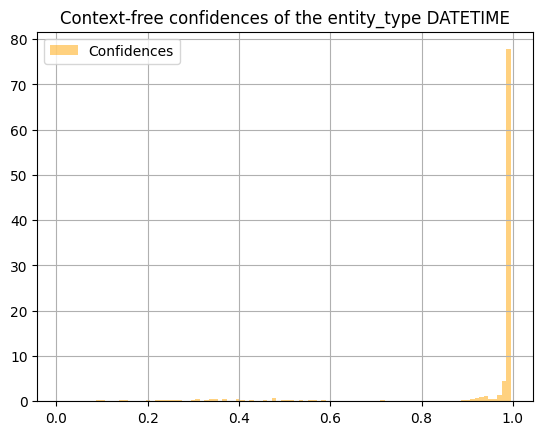

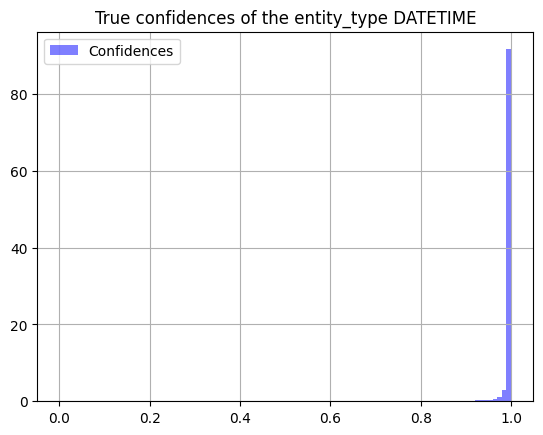

DEM


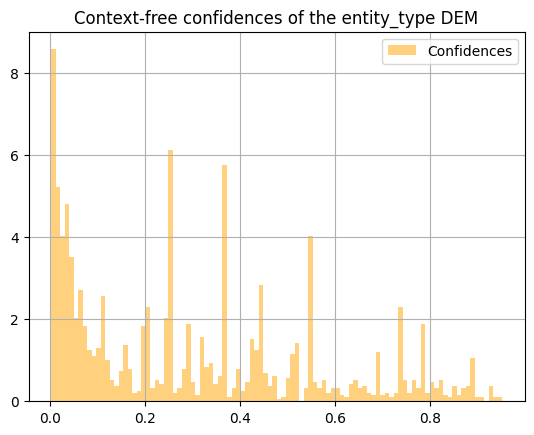

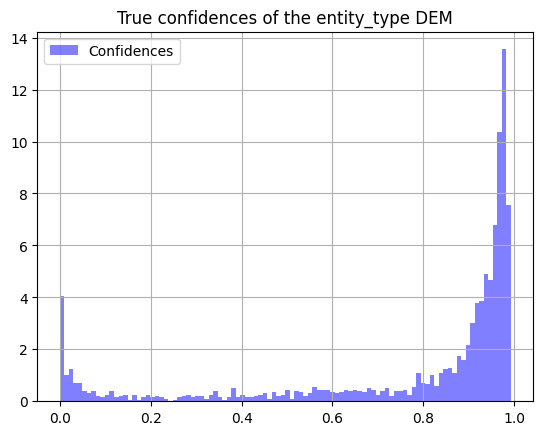

LOC


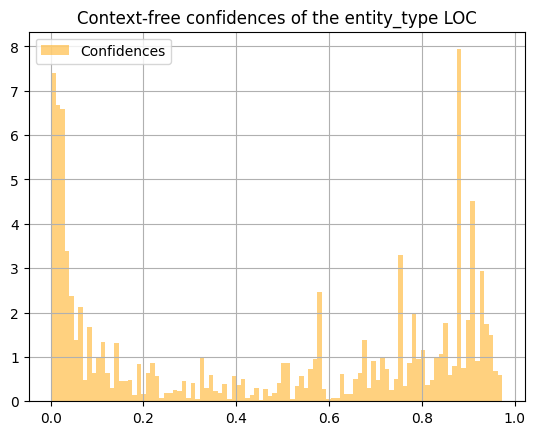

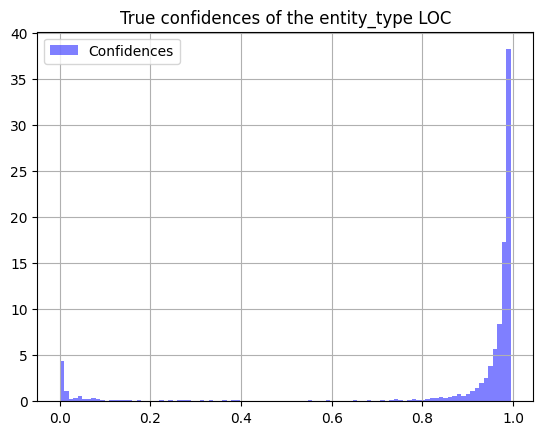

MISC


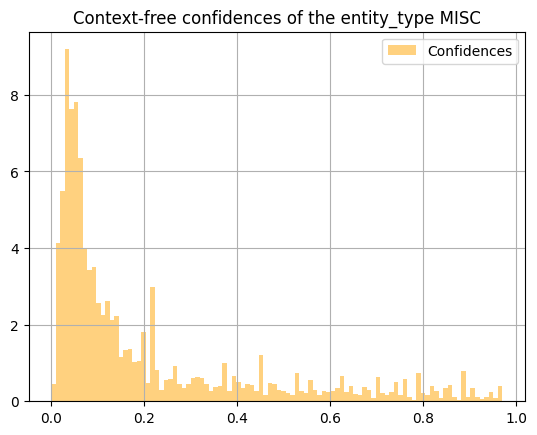

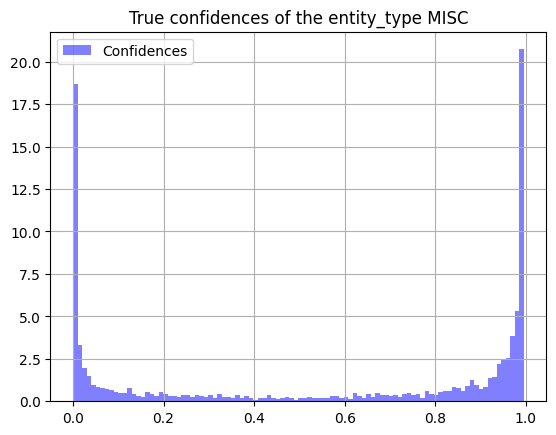

QUANTITY


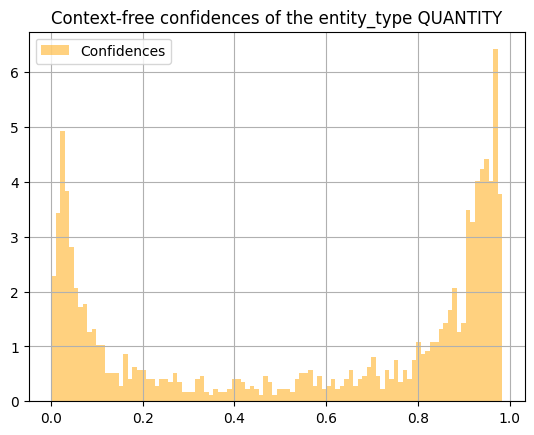

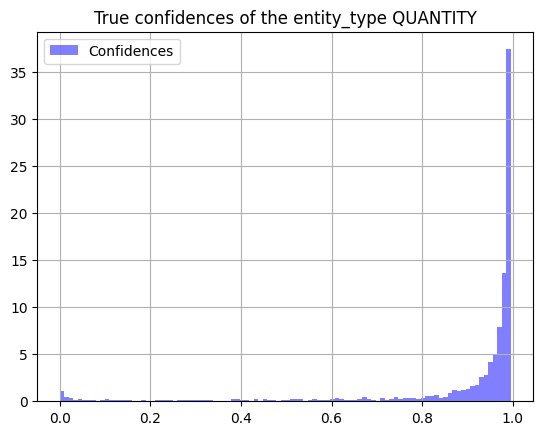

ORG


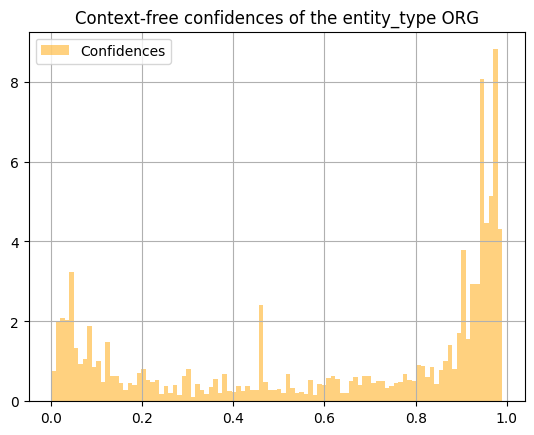

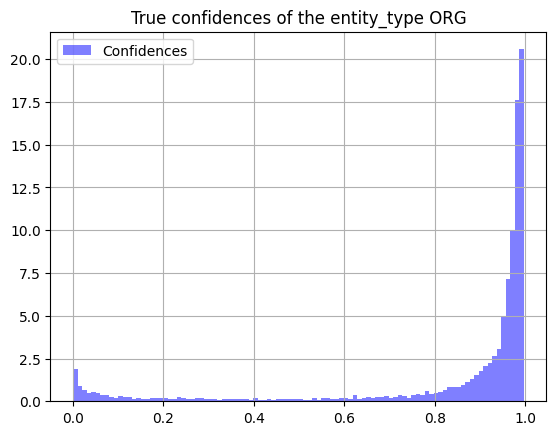

In [12]:
import numpy as np
import matplotlib.pyplot as plt

entity_string_to_int  = {
    'O': -1,
    'PERSON': 0,
    'CODE': 1,
    'LOC': 2,
    'ORG': 3,
    'DEM': 4,
    'DATETIME': 5,
    'QUANTITY': 6,
    'MISC': 7
}

entity_int_to_string = {v: k for k, v in entity_string_to_int.items()}    

entity_wise_true_probs = np.load( './entity_wise_probs.npy', allow_pickle=True).item() 
true_probs = np.load( './true_probs_of_all_dict.npy', allow_pickle=True).item() 

entity_labels, entity_hist = zip(*entity_wise_true_probs.items())
true_labels, true_hist = zip(*true_probs.items())

entity_labels = [entity_int_to_string[el] for el in entity_labels]
true_labels = [entity_int_to_string[el] for el in true_labels]

n_seen_masks = 56817
n_diff_docs = 998

for i, l in enumerate(entity_labels):
        

    filtered_pairs = [( hist, label) for label, hist in zip(entity_labels, entity_hist) if label == l]
    curr_entity_hist, curr_entity_labels = zip(*filtered_pairs)
    curr_true_pairs = [( hist, label) for label, hist in zip(true_labels, true_hist) if label == l]
    curr_true_hist, curr_true_labels = zip(*curr_true_pairs)


    print(l)
    plt.figure()
    plt.hist([e for entity_conf in curr_entity_hist for e in entity_conf], bins = 100, density = True, alpha = 0.5, label = 'Confidences', color = 'orange')
    plt.grid()        
    plt.legend()
    title_string1 = f'Context-free confidences of the entity_type {l}'
    plt.title(title_string1)
    plt.show()

    plt.figure()
    plt.hist([e for entity_conf in curr_true_hist for e in entity_conf], bins = 100, density = True, alpha = 0.5, label = 'Confidences', color = 'blue')
    plt.grid()        
    plt.legend()
    title_string2 = f'True confidences of the entity_type {l}'
    plt.title(title_string2)
    plt.show()
    

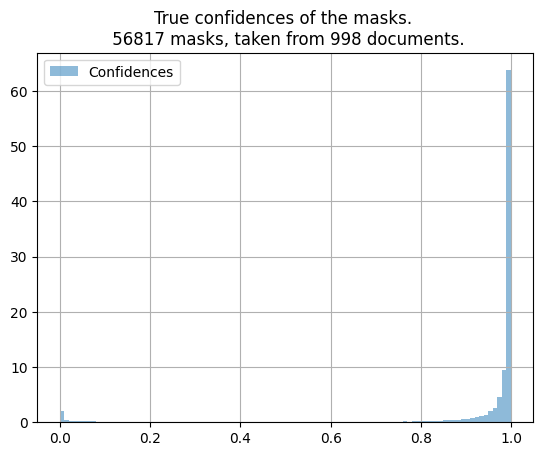

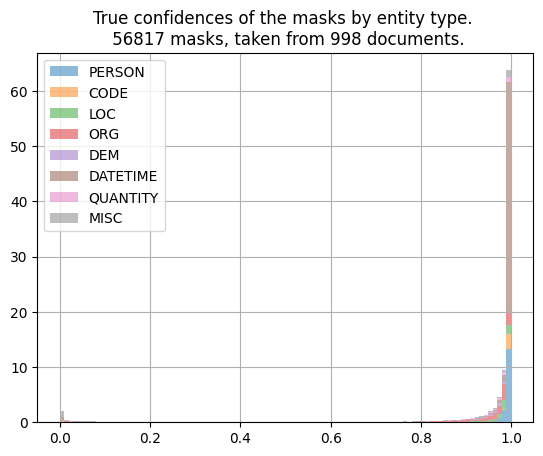

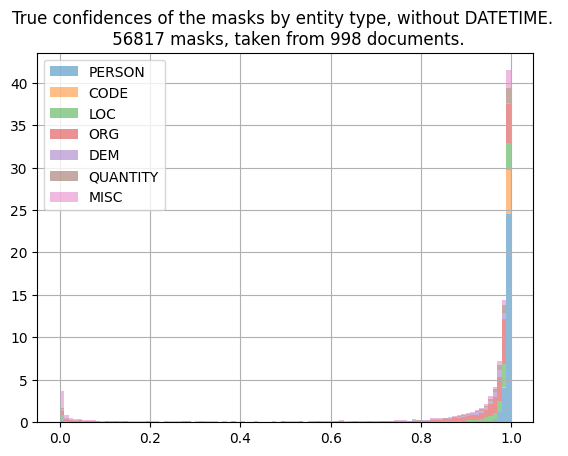

In [16]:
entity_string_to_int  = {
    'O': -1,
    'PERSON': 0,
    'CODE': 1,
    'LOC': 2,
    'ORG': 3,
    'DEM': 4,
    'DATETIME': 5,
    'QUANTITY': 6,
    'MISC': 7
}

entity_int_to_string = {v: k for k, v in entity_string_to_int.items()}    

entity_wise_true_probs = np.load( './true_probs_of_all_dict.npy', allow_pickle=True).item() 
entity_labels, entity_hist = zip(*entity_wise_true_probs.items())
entity_labels = [entity_int_to_string[el] for el in entity_labels]
n_seen_masks = 56817
n_diff_docs = 998


plt.figure()
plt.hist([e for entity_conf in entity_hist for e in entity_conf], bins = 100, density = True, alpha = 0.5, label = 'Confidences')
plt.grid()        
plt.legend()
title_string2 = f'True confidences of the masks. \n {n_seen_masks} masks, taken from {n_diff_docs} documents.'
plt.title(title_string2)
plt.show()
#plt.savefig( self.figpath + 'context_free_confidence_histogram.svg')


plt.figure()
plt.hist(entity_hist, bins = 100, density = True, stacked = True, alpha=0.5, label = entity_labels)
title_string3 = f'True confidences of the masks by entity type. \n {n_seen_masks} masks, taken from {n_diff_docs} documents.'
plt.title(title_string3)
plt.legend()
plt.grid() 
plt.show()
#plt.savefig( self.figpath + 'context_free_confidence_entity_wise_histogram.svg')

filtered_pairs = [( hist, label) for label, hist in zip(entity_labels, entity_hist) if label != "DATETIME"]
entity_hist_no_datetime, entity_labels_no_datetime = zip(*filtered_pairs)

plt.figure()
plt.hist(entity_hist_no_datetime, bins = 100, density = True, stacked = True, alpha=0.5, label = entity_labels_no_datetime)
title_string4 = f'True confidences of the masks by entity type, without DATETIME. \n {n_seen_masks} masks, taken from {n_diff_docs} documents.'
plt.title(title_string4)
plt.legend()
plt.grid() 
plt.show()
#plt.savefig( self.figpath + 'context_free_confidence_entity_wise_histogram_no_datetime.svg')


In [ ]:
entity_wise_true_probs = np.load( './true_probs_of_all_dict.npy', allow_pickle=True).item() 
print(entity_wise_probs.keys())


dict_keys([0, 1, 2, 3, 4, 5, 6, 7])
